<a href="https://colab.research.google.com/github/bluexpired/mean-revesion-strategies/blob/main/Pair_Trading2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 페어 선정 반도체 기업



In [ ]:
import itertools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.stattools import coint # 공적분

from statsmodels.tsa.stattools import adfuller # ADF 검정

#적은 샘플 반도체
tickers = [
    "NVDA",
    "AMD",
    "AVGO",
    "QCOM",
    "TXN",
    "ADI",
    "MU",
    "INTC",
    "AMAT",
    "LRCX",
]
train_start = '2015-01-01'
train_end = '2020-01-01'

data = yf.download(tickers, start=train_start, end=train_end, auto_adjust = True)
close = data['Close'] #close column에 종가
data.head()

[*********************100%***********************]  10 of 10 completed


Price           Close                                                  \
Ticker            ADI       AMAT   AMD      AVGO       INTC      LRCX   
Date                                                                    
2015-01-02  44.095264  21.710476  2.67  7.532591  27.896460  6.790661   
2015-01-05  43.293388  21.014627  2.66  7.412176  27.581890  6.707753   
2015-01-06  42.277145  20.223099  2.63  7.243600  27.067846  6.595787   
2015-01-07  42.721760  20.414461  2.58  7.439269  27.635592  6.629973   
2015-01-08  43.475990  21.066813  2.61  7.811044  28.149641  6.801770   

Price                                                  ...   Volume            \
Ticker             MU      NVDA       QCOM        TXN  ...      ADI      AMAT   
Date                                                   ...                      
2015-01-02  33.886013  0.482423  53.789658  38.903564  ...  1323200   6910200   
2015-01-05  32.940132  0.474275  53.536213  38.299786  ...  1445200  11419800   
2015-01-06  32.052753  0.459896  52.775837  37.666916  ...  1707500  19678300   
2015-01-07  31.301903  0.458697  53.391376  38.343433  ...  1723000  15710300   
2015-01-08  32.832863  0.475952  53.956211  38.969032  ...  1874900  16696900   

Price                                                                    \
Ticker           AMD      AVGO      INTC      LRCX        MU       NVDA   
Date                                                                      
2015-01-02         0  13500000  23605600   8306000  15138200  113680000   
2015-01-05   8878200  15596000  32785000  14408000  23706600  197952000   
2015-01-06  13912500  22194000  30847600  23414000  40092000  197764000   
2015-01-07  12377600  30907000  27725200  15085000  52552300  321808000   
2015-01-08  11136600  33265000  31765400  18713000  31947100  283780000   

Price                          
Ticker          QCOM      TXN  
Date                           
2015-01-02   6662700  4020100  
2015-01-05  12042800  5599300  
2015-01-06  11094000  5468400  
2015-01-07  10030700  4577100  
2015-01-08  10937200  6295200  

[5 rows x 50 columns]

In [ ]:
close.head()

Ticker,ADI,AMAT,AMD,AVGO,INTC,LRCX,MU,NVDA,QCOM,TXN
Date,,,,,,,,,,
2015-01-02,44.095268,21.710468,2.67,7.532590,27.896456,6.790660,33.886009,0.482423,53.789654,39.102753
2015-01-05,43.293377,21.014620,2.66,7.412179,27.581900,6.707752,32.940132,0.474275,53.536205,38.495888
2015-01-06,42.277145,20.223099,2.63,7.243600,27.067846,6.595786,32.052757,0.459896,52.775856,37.859760
2015-01-07,42.721752,20.414461,2.58,7.439269,27.635597,6.629975,31.301905,0.458697,53.391399,38.539745
2015-01-08,43.475983,21.066816,2.61,7.811046,28.149641,6.801769,32.832867,0.475952,53.956223,39.168552


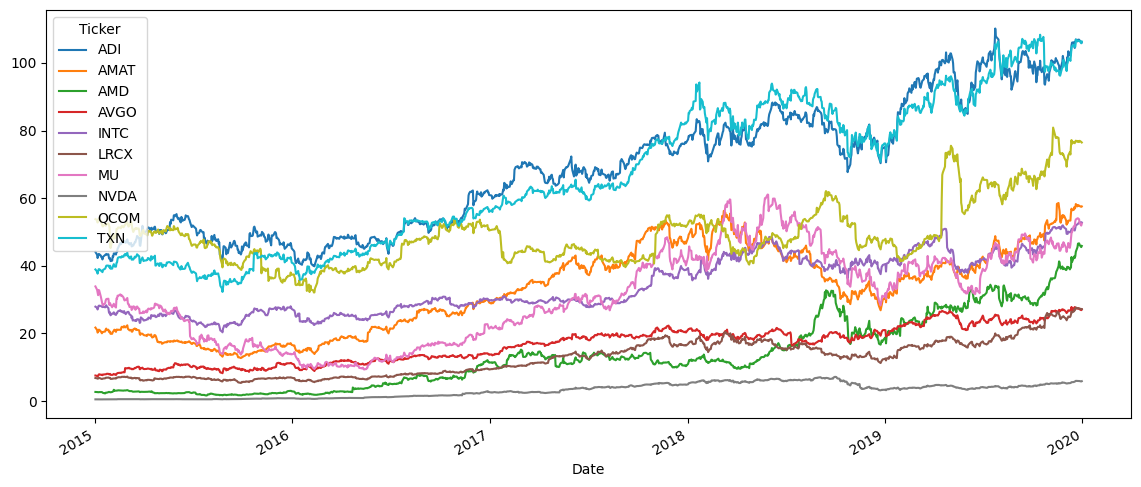

In [ ]:
close.plot(figsize = (14, 6))
plt.show()

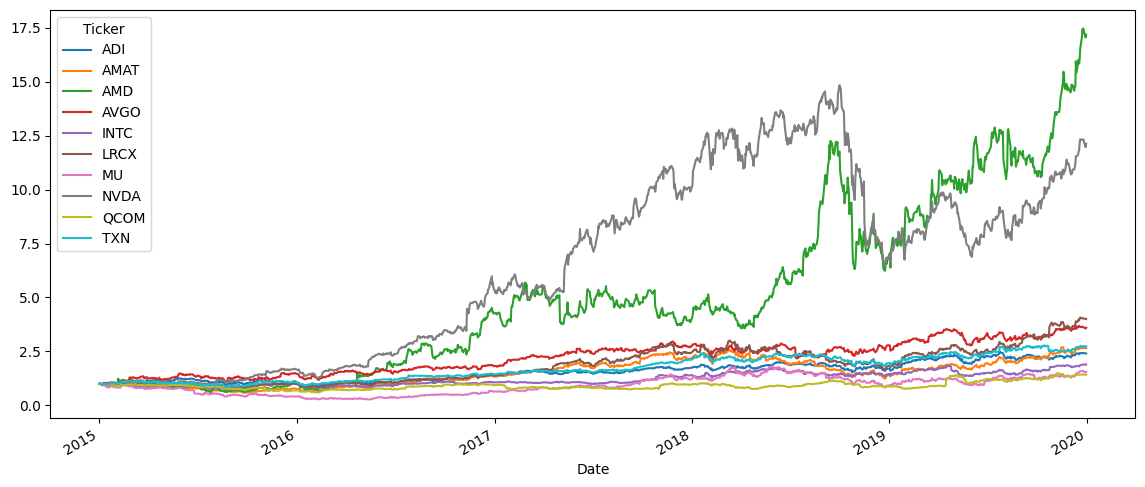

In [ ]:
normalized_price = close / close.iloc[0] # 모든 시작을 1로 만들기
normalized_price.plot(figsize = (14, 6))
plt.show()               #같은 시작기준으로 만들어진 상승률 그래프

A. 상관관계

In [ ]:
from logging import log
log_price = np.log(close) #로그가격
log_return = log_price.diff().dropna() #로그수익률 / 현재 - 이전
standard_return = close.pct_change().dropna()  #rets    일반수익률

correlation_matrix = log_return.corr() #로그 상관관계 matrix      .corr pearson 상관계수임;;
correlation_matrix.round(2)

correlation_candidates = []
for ticker_a, ticker_b in  itertools.combinations(tickers, 2):

  corr = correlation_matrix.loc[ticker_a, ticker_b]

  if corr >= 0.5:
    correlation_candidates.append({
            "ticker_a": ticker_a,
            "ticker_b": ticker_b,
            "return_corr": corr,
        })
correlation_candidates = pd.DataFrame(correlation_candidates)

correlation_candidates = correlation_candidates.sort_values(
    "return_corr",
    ascending=False,
)

# corr .5 이상만 남기고 내림차순
# 상관관계는 결국 단기적인 움직임을 보여줌. 전체적인 경향성 흐름을 볼려면 공적분도 봐야함

correlation_candidates

,ticker_a,ticker_b,return_corr
22,AMAT,LRCX,0.837201
9,TXN,ADI,0.765697
13,TXN,LRCX,0.662157
11,TXN,INTC,0.653449
17,ADI,LRCX,0.651000
12,TXN,AMAT,0.646553
16,ADI,AMAT,0.627937
18,MU,AMAT,0.614012
6,AVGO,ADI,0.603479
19,MU,LRCX,0.602480


B. Engle–Granger 공적분

p-val 이 작은 값 찾기

In [ ]:
cointegration_results = []
for _, row in correlation_candidates.iterrows():
  ticker_a = row["ticker_a"]
  ticker_b = row["ticker_b"]
  corr = row["return_corr"]

  # 두 종목의 공통 날짜만 남긴다.
  pair_price = log_price[[ticker_a, ticker_b]].dropna()

  # 관측치가 너무 적은 pair는 제외한다.
  if len(pair_price) < 500:
        continue

  # A를 종속변수, B를 설명변수로 Engle-Granger 검정
  score, p_value, _ = coint(
        pair_price[ticker_a],
        pair_price[ticker_b],
    )

  cointegration_results.append({
        "ticker_a": ticker_a,
        "ticker_b": ticker_b,
        "return_corr": row["return_corr"],
        "coint_pvalue": p_value,
    })

cointegration_results = pd.DataFrame(cointegration_results)

cointegration_results = cointegration_results.sort_values(
    "coint_pvalue"
)

cointegration_results

,ticker_a,ticker_b,return_corr,coint_pvalue
20,AVGO,LRCX,0.529401,0.010125
3,TXN,INTC,0.653449,0.025969
8,AVGO,ADI,0.603479,0.030613
19,AVGO,AMAT,0.531241,0.034188
22,NVDA,MU,0.504313,0.040100
10,AVGO,TXN,0.590697,0.044812
14,ADI,MU,0.549394,0.069401
11,ADI,INTC,0.585479,0.079123
4,ADI,LRCX,0.651000,0.141270
15,NVDA,AMAT,0.543664,0.171078


In [ ]:
cointegrated_pairs = cointegration_results[
    cointegration_results["coint_pvalue"] < 0.05
].copy()

cointegrated_pairs

,ticker_a,ticker_b,return_corr,coint_pvalue
20,AVGO,LRCX,0.529401,0.010125
3,TXN,INTC,0.653449,0.025969
8,AVGO,ADI,0.603479,0.030613
19,AVGO,AMAT,0.531241,0.034188
22,NVDA,MU,0.504313,0.040100
10,AVGO,TXN,0.590697,0.044812


C. Hedge Ratio and Spread

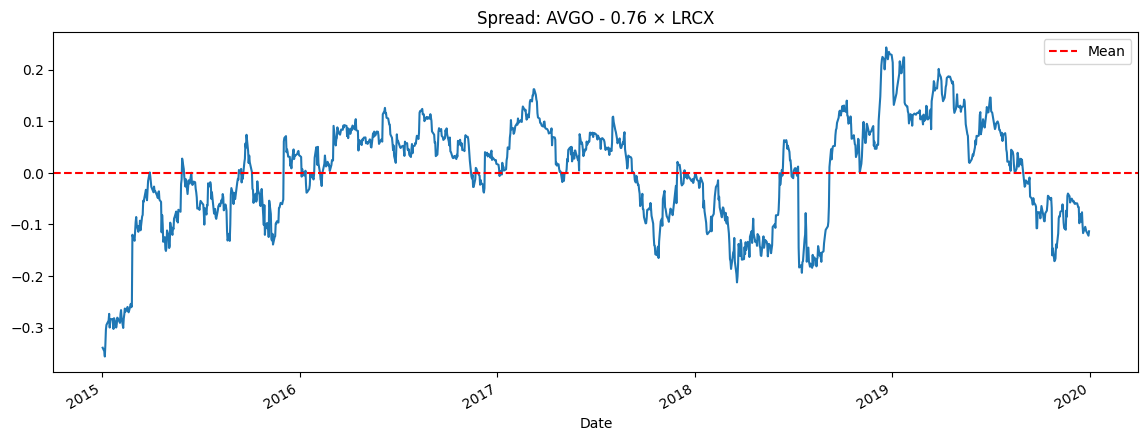

In [ ]:
best_pair = cointegrated_pairs.iloc[0]

ticker_a = best_pair["ticker_a"]
ticker_b = best_pair["ticker_b"]

pair_price = log_price[[ticker_a, ticker_b]].dropna()

beta, alpha = np.polyfit(     #find a, b in 회귀식
    pair_price[ticker_b],
    pair_price[ticker_a],
    1,
)
#회귀 결과로 allpha beta 구하고, 진짜값 - 예상값 = spread
# epsil = y - alpha - beta * x
# 잔차 구하기
spread = (
    pair_price[ticker_a]
    - alpha
    - beta * pair_price[ticker_b]
)

spread.plot(figsize=(14, 5))

plt.axhline(
    spread.mean(),
    color="red",
    linestyle="--",
    label="Mean",
)
# mean = spread 의 산술평균
plt.title(f"Spread: {ticker_a} - {beta:.2f} × {ticker_b}")
plt.legend()
plt.show()


D. ADF 검정 -> spread의 정상성 확인

ADF 검정의 귀무가설  spread에 단위근이 있어 비정상적이다

In [ ]:
adf_result = adfuller(
    spread,

    # AIC로 사용할 lag 수를 자동 선택 ADF 회귀식에 포함할 과거 spread 변화량의 lag 개수를  AIC 기준으로 자동 선택한다.
    autolag="AIC",
)

adf_statistic = adf_result[0]   #일반적으로 ADF statistic이 더 작은 음수일수록 단위근 귀무가설을 기각할 증거가 강해져.
adf_pvalue = adf_result[1]

print("ADF statistic:", adf_statistic) # adf 검정통계량
print("ADF p-value:", adf_pvalue) # pval

if adf_pvalue < 0.05:
    print("spread가 정상적이라는 증거가 있음")
else:
    print("spread가 정상적이라고 보기 어려움")

ADF statistic: -3.892492721067563
ADF p-value: 0.0020907964958189057
spread가 정상적이라는 증거가 있음


E. 평균회귀 반감기 계산
    평균으로 돌아온다면, 대략 얼마만에 돌아오는가
1.   항목 추가
2.   항목 추가




In [ ]:
# 전날 spread
lagged_spread = spread.shift(1)

# 오늘 spread와 전날 spread의 변화량
spread_change = spread.diff()

half_life_data = pd.DataFrame({
    "spread_change": spread_change,
    "lagged_spread": lagged_spread,
}).dropna()   #두 열의 관계가 반대 방향이어야 평균으로 되돌아와.

b, intercept = np.polyfit(
    half_life_data["lagged_spread"],
    half_life_data["spread_change"],
    1,
)

print("Mean-reversion coefficient:", b) #회귀계수 b

if b < 0:
    half_life = -np.log(2) / b
else:
    # b가 양수라면 평균으로 돌아가기보다 벌어지는 관계
    half_life = np.inf

print("Half-life:", half_life, "trading days")

Mean-reversion coefficient: -0.019024487587135167
Half-life: 36.43447306452914 trading days


In [ ]:
def analyze_pair(
    log_price,
    ticker_a,
    ticker_b,
    min_observations=500,
):
    """
    두 종목의 공적분 관계와 평균회귀 특성을 계산한다.

    Parameters
    ----------
    log_price : DataFrame
        종목별 로그가격
    ticker_a, ticker_b : str
        검사할 두 종목
    min_observations : int
        필요한 최소 공통 관측치

    Returns
    -------
    dict 또는 None
        pair의 통계량. 데이터가 부족하면 None.
    """

    # 두 종목 모두 가격이 존재하는 날짜만 선택
    pair = log_price[[ticker_a, ticker_b]].dropna()

    if len(pair) < min_observations:
        return None

    y = pair[ticker_a]
    x = pair[ticker_b]

    # 1. Engle-Granger 공적분 검정
    _, coint_pvalue, _ = coint(y, x)

    # 2. y = alpha + beta*x 회귀
    beta, alpha = np.polyfit(x, y, 1)

    # 3. 회귀 잔차를 spread로 정의
    spread = y - alpha - beta * x

    # 4. spread의 ADF 검정
    adf_pvalue = adfuller(
        spread,
        autolag="AIC",
    )[1]

    # 5. 반감기 계산
    half_life_data = pd.DataFrame({
        "spread_change": spread.diff(),
        "lagged_spread": spread.shift(1),
    }).dropna()

    reversion_coefficient, _ = np.polyfit(
        half_life_data["lagged_spread"],
        half_life_data["spread_change"],
        1,
    )

    if reversion_coefficient < 0:
        half_life = -np.log(2) / reversion_coefficient
    else:
        half_life = np.inf

    return {
        "ticker_a": ticker_a,
        "ticker_b": ticker_b,
        "n_observations": len(pair),
        "coint_pvalue": coint_pvalue,
        "adf_pvalue": adf_pvalue,
        "alpha": alpha,
        "hedge_ratio": beta,
        "half_life": half_life,
    }

In [ ]:
analyze_pair(
    log_price,
    "AMD",
    "NVDA",
)

{'ticker_a': 'AMD',
 'ticker_b': 'NVDA',
 'n_observations': 1258,
 'coint_pvalue': np.float64(0.8213421291686509),
 'adf_pvalue': np.float64(0.617293005916163),
 'alpha': np.float64(1.4112005489473558),
 'hedge_ratio': np.float64(0.9748278219460172),
 'half_life': np.float64(214.51864664778518)}

Finish

In [ ]:
all_results = []

for _, row in correlation_candidates.iterrows():

    result = analyze_pair(
        log_price=log_price,
        ticker_a=row["ticker_a"],
        ticker_b=row["ticker_b"],
    )

    if result is None:
        continue

    # 앞에서 계산한 상관계수도 결과에 추가
    result["return_corr"] = row["return_corr"]

    all_results.append(result)

results = pd.DataFrame(all_results)

results.head()



selected_pairs = results[
    # 공적분 관계
    (results["coint_pvalue"] < 0.05)

    # 직접 만든 spread도 정상적이어야 함
    & (results["adf_pvalue"] < 0.05)

    # hedge ratio가 음수인 특이한 조합 제외
    & (results["hedge_ratio"] > 0)

    # 너무 빠르거나 너무 느린 평균회귀 제외, 반감기 느림
    & (results["half_life"].between(2, 60))
].copy()


selected_pairs = selected_pairs.sort_values(
    by=[
        "coint_pvalue",
        "half_life",
    ],
    ascending=[
        True,
        True,
    ],
)

selected_pairs

,ticker_a,ticker_b,n_observations,coint_pvalue,adf_pvalue,alpha,hedge_ratio,half_life,return_corr
20,AVGO,LRCX,1258,0.010125,0.002091,0.902659,0.759980,36.434473,0.529401
3,TXN,INTC,1258,0.025969,0.006173,-0.488638,1.324490,46.606847,0.653449
8,AVGO,ADI,1258,0.030613,0.007502,-2.284570,1.202894,40.843948,0.603479
19,AVGO,AMAT,1258,0.034188,0.008527,0.163852,0.758557,56.717377,0.531241
10,AVGO,TXN,1258,0.044812,0.011760,-1.311596,0.982152,46.059960,0.590697


In [ ]:
selected_pairs.to_csv(
    "selected_pairs.csv",
    index=False,
)

2(1) 설정

처음에는 임계값을 임의로 최적화하지 않는다. 이 값들을 기준 전략으로 고정한 뒤,
 다음 단계의 walk-forward 검증에서 후보 값들을 비교한다.

In [ ]:
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)


TEST_START = "2020-01-01"
TEST_END = None

INITIAL_CAPITAL = 100_000.0     # 초기 모의투자금 $100,000
CAPITAL_ALLOCATION = 0.50       # 한 pair의 gross exposure에 계좌의 50% 사용

LOOKBACK = 60                   # z-score가 보는 과거 거래일 수
ENTRY_Z = 2.0                   # 진입 임계값
EXIT_Z = 0.5                    # 평균 근처 청산 임계값
STOP_Z = 4.0                    # 관계가 더 벌어질 때 통계적 손절
ACCOUNT_LOSS_LIMIT = 0.01       # 한 거래에서 계좌자산의 1% 손실 시 청산

COMMISSION_BPS = 5              # 매수/매도 명목금액의 5bp
SLIPPAGE_BPS = 5                # 슬리피지 5bp
TOTAL_COST_RATE = (COMMISSION_BPS + SLIPPAGE_BPS) / 10_000

In [ ]:
if "selected_pairs" not in globals():
    csv_path = Path("selected_pairs.csv")
    if not csv_path.exists():
        raise FileNotFoundError(
            "selected_pairs.csv가 없습니다. 먼저 페어 선정 코드를 실행하거나 CSV를 업로드하세요."
        )
    selected_pairs = pd.read_csv(csv_path)

required_columns = {
    "ticker_a", "ticker_b", "alpha", "hedge_ratio", "half_life"
}
missing_columns = required_columns.difference(selected_pairs.columns)
if missing_columns:
    raise ValueError(f"선정 결과에 필요한 열이 없습니다: {sorted(missing_columns)}")

# 우선 1등 pair 하나로 엔진이 올바르게 작동하는지 확인한다.
chosen = selected_pairs.iloc[0]
ticker_a = chosen["ticker_a"]
ticker_b = chosen["ticker_b"]
alpha = float(chosen["alpha"])
beta = float(chosen["hedge_ratio"])
half_life = float(chosen["half_life"])

# 평균회귀 예상시간의 약 2배가 지나도 돌아오지 않으면 시간 손절한다.
MAX_HOLDING_DAYS = max(5, int(np.ceil(2 * half_life)))

print({
    "ticker_a": ticker_a,
    "ticker_b": ticker_b,
    "alpha": round(alpha, 4),
    "hedge_ratio": round(beta, 4),
    "half_life": round(half_life, 2),
    "max_holding_days": MAX_HOLDING_DAYS,
})


{'ticker_a': 'AVGO', 'ticker_b': 'LRCX', 'alpha': 0.9027, 'hedge_ratio': 0.76, 'half_life': 36.43, 'max_holding_days': 73}


3. 테스트 데이터와 신호

 spread는 학습 구간의 alpha와 beta를 고정해서 계산한다.
z-score의 평균과 표준편차는 각 시점까지 이용 가능한 과거 데이터만 사용한다.


In [ ]:
download = yf.download(
    [ticker_a, ticker_b],
    start=TEST_START,
    end=TEST_END,
    auto_adjust=True,
    progress=False,
)
# z-score을 만들기

close = download["Close"][[ticker_a, ticker_b]].dropna().astype(float)
if len(close) <= LOOKBACK:
    raise ValueError("테스트 데이터가 LOOKBACK보다 짧습니다.")

log_price = np.log(close)
spread = log_price[ticker_a] - alpha - beta * log_price[ticker_b] #spread 구하기

# 현재 값을 포함한 직전 LOOKBACK일 통계다.
# 미래 날짜의 값은 어느 셀에서도 사용하지 않는다.
rolling_mean = spread.rolling(LOOKBACK, min_periods=LOOKBACK).mean() #최근 60일 spread 평균 구하기
rolling_std = spread.rolling(LOOKBACK, min_periods=LOOKBACK).std(ddof=1) #spread 표준편차 구하기
zscore = ((spread - rolling_mean) / rolling_std).replace([np.inf, -np.inf], np.nan)

signal_frame = pd.DataFrame({
    ticker_a: close[ticker_a],
    ticker_b: close[ticker_b],
    "spread": spread,
    "zscore": zscore,
}).dropna(subset=["zscore"])

signal_frame.head()

,AVGO,LRCX,spread,zscore
Date,,,,
2020-03-27,20.109779,22.561888,-0.269751,-0.691503
2020-03-30,20.930941,23.878820,-0.272842,-0.707883
2020-03-31,20.668550,22.447775,-0.238490,-0.202532
2020-04-01,19.494341,20.888597,-0.242270,-0.230581
2020-04-02,20.665064,20.630442,-0.174499,0.775132


 4. 이벤트 기반 백테스트 함수

side = +1`은 spread 롱(A 롱, B 숏), `side = -1`은 spread 숏(A 숏, B 롱)이다.

 로그가격 회귀에서 beta는 수익률 민감도로 해석할 수 있으므로 명목금액 비중을
`1 : |beta|`로 나눈다. 실제 체결 주식 수는 진입일 가격으로 계산하고 청산까지 고정한다.
 이렇게 하면 매일 목표비중으로 몰래 재조정하는 오류를 피할 수 있다.

In [ ]:
def backtest_one_pair(
    frame,
    ticker_a,
    ticker_b,
    beta,
    initial_capital=100_000.0,
    capital_allocation=0.50,
    entry_z=2.0,
    exit_z=0.5,
    stop_z=4.0,
    account_loss_limit=0.01,
    max_holding_days=40,
    cost_rate=0.001,
):
    cash = float(initial_capital)
    shares_a = 0.0
    shares_b = 0.0
    side = 0                       # 0=현금, +1=spread long, -1=spread short
    entry_equity = None
    entry_date = None
    entry_z_value = None
    holding_days = 0
    trade_id = 0

    equity_rows = []
    order_rows = []
    trade_rows = []

    dates = frame.index

    def current_equity(price_a, price_b):
        return cash + shares_a * price_a + shares_b * price_b

    def place_order(date, symbol, quantity, price, reason, current_trade_id):
        """시장가 주문을 단순화: 지정 종가 체결 + 명목금액 비례 비용."""
        nonlocal cash
        notional = quantity * price
        fee = abs(notional) * cost_rate
        cash -= notional + fee
        order_rows.append({
            "trade_id": current_trade_id,
            "date": date,
            "symbol": symbol,
            "action": "BUY" if quantity > 0 else "SELL",
            "quantity": quantity,
            "price": price,
            "notional": notional,
            "fee": fee,
            "reason": reason,
        })
        return fee

    for i, date in enumerate(dates):
        price_a = float(frame.loc[date, ticker_a])
        price_b = float(frame.loc[date, ticker_b])
        z_today = float(frame.loc[date, "zscore"])

        # 어제 종가에서 확인한 신호를 오늘 종가에 체결한다.
        z_signal = np.nan if i == 0 else float(frame.iloc[i - 1]["zscore"])

        equity_before_orders = current_equity(price_a, price_b)
        exit_reason = None

        if side != 0:
            holding_days += 1
            trade_return_on_account = (
                equity_before_orders / entry_equity - 1
                if entry_equity and entry_equity > 0 else 0
            )

            # 현재 보유 방향에 따라 평균복귀 청산 조건이 다르다.
            mean_reversion_exit = (
                (side == 1 and z_signal >= -exit_z)
                or (side == -1 and z_signal <= exit_z)
            )
            statistical_stop = (
                (side == 1 and z_signal <= -stop_z)
                or (side == -1 and z_signal >= stop_z)
            )
            capital_stop = trade_return_on_account <= -account_loss_limit
            time_stop = holding_days >= max_holding_days

            if mean_reversion_exit:
                exit_reason = "MEAN_REVERSION"
            elif statistical_stop:
                exit_reason = "Z_STOP"
            elif capital_stop:
                exit_reason = "CAPITAL_STOP"
            elif time_stop:
                exit_reason = "TIME_STOP"

        # 기존 포지션 청산
        if side != 0 and exit_reason is not None:
            exit_fees = 0.0
            exit_fees += place_order(
                date, ticker_a, -shares_a, price_a, exit_reason, trade_id
            )
            exit_fees += place_order(
                date, ticker_b, -shares_b, price_b, exit_reason, trade_id
            )
            shares_a = 0.0
            shares_b = 0.0
            exit_equity = cash

            trade_rows.append({
                "trade_id": trade_id,
                "entry_date": entry_date,
                "exit_date": date,
                "side": "LONG_SPREAD" if side == 1 else "SHORT_SPREAD",
                "entry_z": entry_z_value,
                "exit_z_signal": z_signal,
                "holding_days": holding_days,
                "exit_reason": exit_reason,
                "entry_equity": entry_equity,
                "exit_equity": exit_equity,
                "pnl": exit_equity - entry_equity,
                "return_on_account": exit_equity / entry_equity - 1,
                "exit_fees": exit_fees,
            })

            side = 0
            entry_equity = None
            entry_date = None
            entry_z_value = None
            holding_days = 0

        # 포지션이 없을 때 신규 진입. 같은 날 청산 후 즉시 재진입은 허용하지 않는다.
        entered_today = False
        if side == 0 and exit_reason is None and not np.isnan(z_signal):
            new_side = 0
            if z_signal <= -entry_z:
                new_side = 1       # 낮은 spread를 롱
            elif z_signal >= entry_z:
                new_side = -1      # 높은 spread를 숏

            if new_side != 0:
                trade_id += 1
                side = new_side
                entry_date = date
                entry_z_value = z_signal
                entry_equity = cash
                holding_days = 0

                # 진입 직전 계좌자산 중 일부만 gross exposure로 사용한다.
                gross_notional = entry_equity * capital_allocation
                denominator = 1.0 + abs(beta)
                notional_a = side * gross_notional / denominator
                notional_b = -side * abs(beta) * gross_notional / denominator
                quantity_a = notional_a / price_a
                quantity_b = notional_b / price_b

                place_order(
                    date, ticker_a, quantity_a, price_a, "ENTRY", trade_id
                )
                place_order(
                    date, ticker_b, quantity_b, price_b, "ENTRY", trade_id
                )
                shares_a = quantity_a
                shares_b = quantity_b
                entered_today = True

        equity_after_orders = current_equity(price_a, price_b)
        equity_rows.append({
            "date": date,
            "equity": equity_after_orders,
            "cash": cash,
            "market_value_a": shares_a * price_a,
            "market_value_b": shares_b * price_b,
            "gross_exposure": abs(shares_a * price_a) + abs(shares_b * price_b),
            "side": side,
            "zscore": z_today,
            "entered_today": entered_today,
            "exited_today": exit_reason is not None,
        })

    # 테스트 마지막 날에 열린 포지션이 있으면 강제청산하여 총손익을 확정한다.
    if side != 0:
        date = dates[-1]
        price_a = float(frame.loc[date, ticker_a])
        price_b = float(frame.loc[date, ticker_b])
        final_z = float(frame.loc[date, "zscore"])
        place_order(date, ticker_a, -shares_a, price_a, "END_OF_TEST", trade_id)
        place_order(date, ticker_b, -shares_b, price_b, "END_OF_TEST", trade_id)
        shares_a = shares_b = 0.0
        exit_equity = cash
        trade_rows.append({
            "trade_id": trade_id,
            "entry_date": entry_date,
            "exit_date": date,
            "side": "LONG_SPREAD" if side == 1 else "SHORT_SPREAD",
            "entry_z": entry_z_value,
            "exit_z_signal": final_z,
            "holding_days": holding_days,
            "exit_reason": "END_OF_TEST",
            "entry_equity": entry_equity,
            "exit_equity": exit_equity,
            "pnl": exit_equity - entry_equity,
            "return_on_account": exit_equity / entry_equity - 1,
            "exit_fees": np.nan,
        })
        equity_rows[-1]["equity"] = cash
        equity_rows[-1]["cash"] = cash
        equity_rows[-1]["market_value_a"] = 0.0
        equity_rows[-1]["market_value_b"] = 0.0
        equity_rows[-1]["gross_exposure"] = 0.0
        equity_rows[-1]["side"] = 0
        equity_rows[-1]["exited_today"] = True

    equity = pd.DataFrame(equity_rows).set_index("date")
    orders = pd.DataFrame(order_rows)
    trades = pd.DataFrame(trade_rows)
    return equity, orders, trades

5 백테스트 실행

In [ ]:
equity, orders, trades = backtest_one_pair(
    frame=signal_frame,
    ticker_a=ticker_a,
    ticker_b=ticker_b,
    beta=beta,
    initial_capital=INITIAL_CAPITAL,
    capital_allocation=CAPITAL_ALLOCATION,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    stop_z=STOP_Z,
    account_loss_limit=ACCOUNT_LOSS_LIMIT,
    max_holding_days=MAX_HOLDING_DAYS,
    cost_rate=TOTAL_COST_RATE,
)

print(f"Orders: {len(orders):,}")
print(f"Completed trades: {len(trades):,}")

Orders: 220
Completed trades: 55


6 결과표

In [ ]:
def make_performance_table(equity, trades, initial_capital):
    daily_return = equity["equity"].pct_change().fillna(0.0)
    total_days = max((equity.index[-1] - equity.index[0]).days, 1)
    years = total_days / 365.25

    final_equity = float(equity["equity"].iloc[-1])
    total_pnl = final_equity - initial_capital
    total_return = final_equity / initial_capital - 1
    cagr = (final_equity / initial_capital) ** (1 / years) - 1 if years > 0 else np.nan
    annual_vol = daily_return.std(ddof=1) * np.sqrt(252)
    sharpe = (
        daily_return.mean() / daily_return.std(ddof=1) * np.sqrt(252)
        if daily_return.std(ddof=1) > 0 else np.nan
    )
    running_peak = equity["equity"].cummax()
    drawdown = equity["equity"] / running_peak - 1
    max_drawdown = drawdown.min()

    if len(trades):
        win_rate = (trades["pnl"] > 0).mean()
        average_trade = trades["pnl"].mean()
        profit_factor = (
            trades.loc[trades["pnl"] > 0, "pnl"].sum()
            / abs(trades.loc[trades["pnl"] < 0, "pnl"].sum())
            if (trades["pnl"] < 0).any() else np.inf
        )
    else:
        win_rate = average_trade = profit_factor = np.nan

    performance = pd.DataFrame({
        "metric": [
            "Initial capital", "Final equity", "Total P&L", "Total return",
            "CAGR", "Annual volatility", "Sharpe ratio", "Maximum drawdown",
            "Number of trades", "Win rate", "Average trade P&L", "Profit factor",
            "Total transaction costs",
        ],
        "value": [
            initial_capital, final_equity, total_pnl, total_return,
            cagr, annual_vol, sharpe, max_drawdown,
            len(trades), win_rate, average_trade, profit_factor,
            orders["fee"].sum() if len(orders) else 0.0,
        ],
    })
    return performance, daily_return, drawdown


performance, daily_return, drawdown = make_performance_table(
    equity, trades, INITIAL_CAPITAL
)

performance

# 보기 좋은 요약 출력
money_metrics = {"Initial capital", "Final equity", "Total P&L", "Average trade P&L", "Total transaction costs"}
percent_metrics = {"Total return", "CAGR", "Annual volatility", "Maximum drawdown", "Win rate"}

for _, row in performance.iterrows():
    name, value = row["metric"], row["value"]
    if name in money_metrics:
        print(f"{name:25s}: ${value:,.2f}")
    elif name in percent_metrics:
        print(f"{name:25s}: {value:.2%}")
    else:
        print(f"{name:25s}: {value:.3f}")

Initial capital          : $100,000.00
Final equity             : $103,513.04
Total P&L                : $3,513.04
Total return             : 3.51%
CAGR                     : 0.54%
Annual volatility        : 5.67%
Sharpe ratio             : 0.124
Maximum drawdown         : -18.34%
Number of trades         : 55.000
Win rate                 : 41.82%
Average trade P&L        : $63.87
Profit factor            : 1.072
Total transaction costs  : $5,955.35


7. 주문표와 완결 거래표

 `orders`는 두 종목 각각의 실제 BUY/SELL 주문을 보여준다.
 `trades`는 양쪽 leg를 한 개의 pair 거래로 묶어 진입·청산·손익을 보여준다.

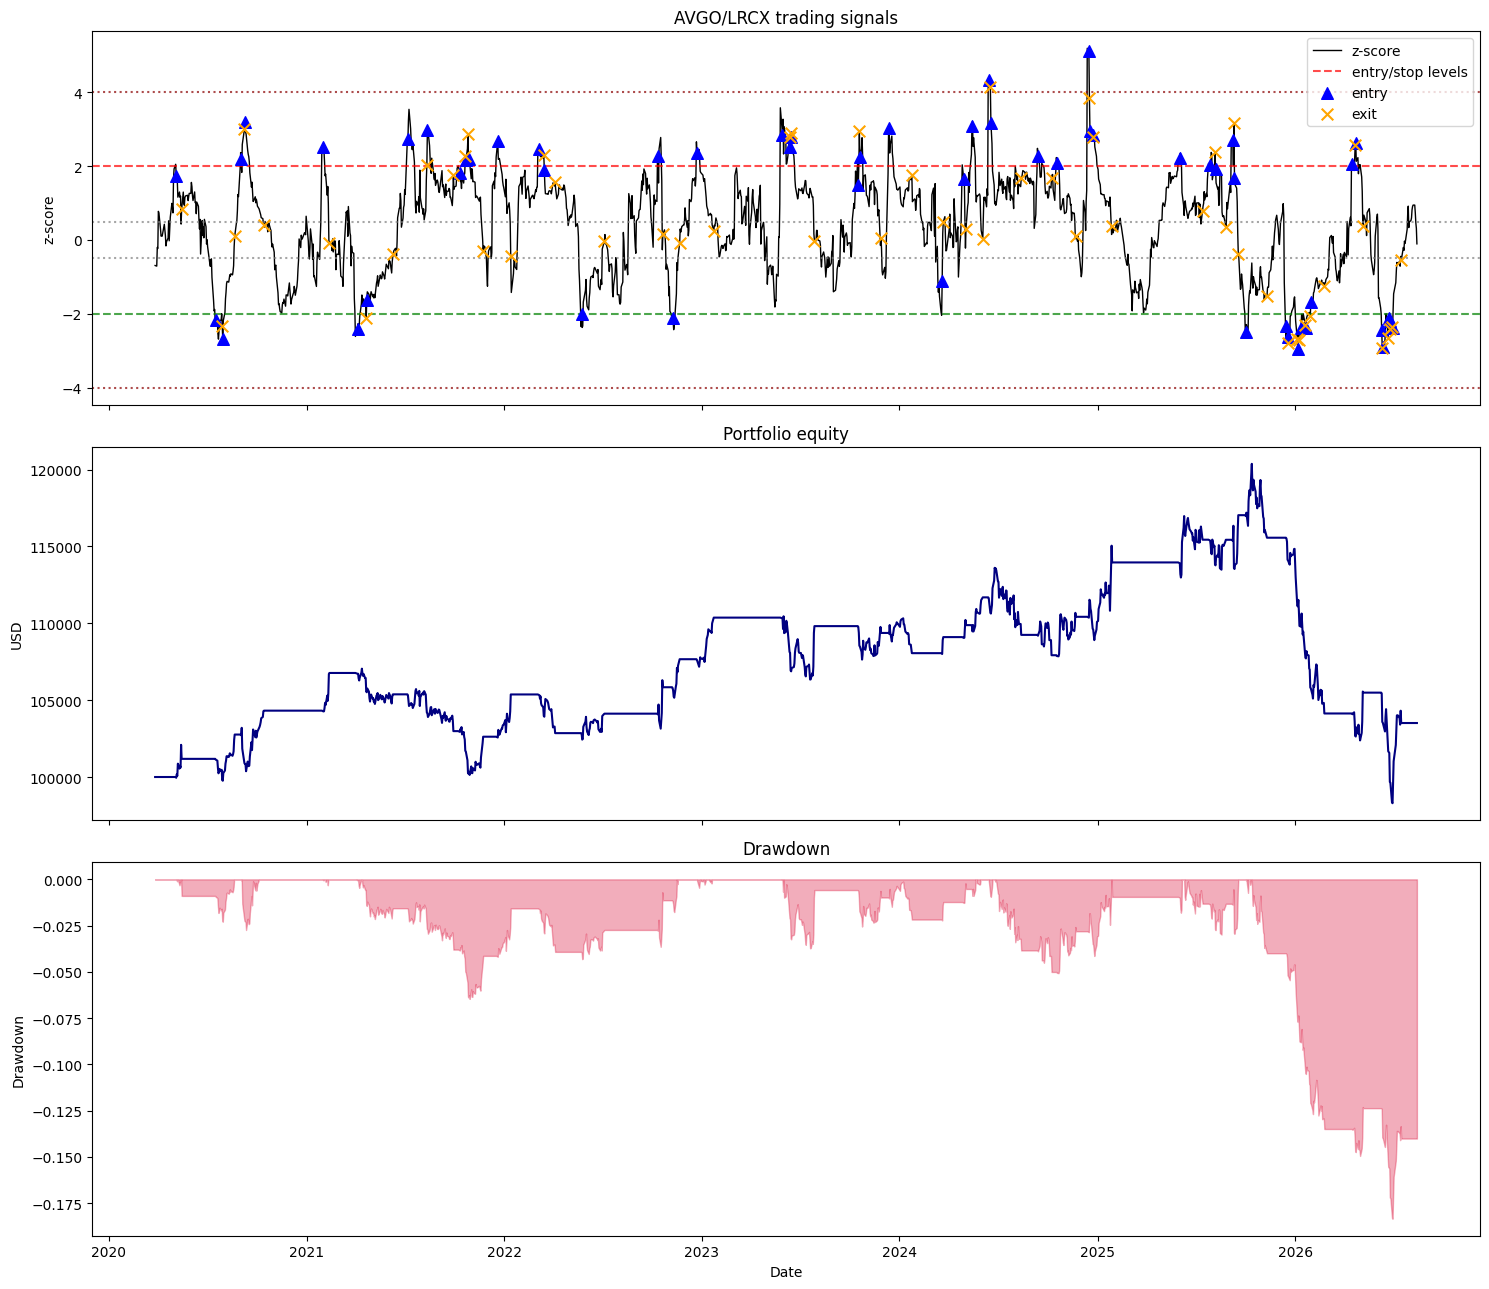

저장 완료:
- performance_summary.csv : 전체 성과표
- order_log.csv           : 종목별 주문표
- trade_log.csv           : pair 단위 거래 및 손익표
- daily_equity.csv         : 일별 자산/포지션/z-score


In [ ]:
orders_display_columns = [
    "trade_id", "date", "symbol", "action", "quantity",
    "price", "notional", "fee", "reason",
]
orders[orders_display_columns].round(4)

# %%
trade_display_columns = [
    "trade_id", "entry_date", "exit_date", "side", "entry_z",
    "exit_z_signal", "holding_days", "exit_reason", "pnl", "return_on_account",
]
trades[trade_display_columns].round(4)

# 8. 매수·매도 지점과 자산 그래프


fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

# (1) z-score와 진입/청산 지점
axes[0].plot(equity.index, equity["zscore"], color="black", lw=1, label="z-score")
axes[0].axhline(ENTRY_Z, color="red", ls="--", alpha=0.7, label="entry/stop levels")
axes[0].axhline(-ENTRY_Z, color="green", ls="--", alpha=0.7)
axes[0].axhline(EXIT_Z, color="gray", ls=":", alpha=0.7)
axes[0].axhline(-EXIT_Z, color="gray", ls=":", alpha=0.7)
axes[0].axhline(STOP_Z, color="darkred", ls=":", alpha=0.7)
axes[0].axhline(-STOP_Z, color="darkred", ls=":", alpha=0.7)

if len(trades):
    entry_dates = pd.to_datetime(trades["entry_date"])
    exit_dates = pd.to_datetime(trades["exit_date"])
    axes[0].scatter(entry_dates, equity.loc[entry_dates, "zscore"], marker="^", s=70,
                    color="blue", label="entry", zorder=3)
    axes[0].scatter(exit_dates, equity.loc[exit_dates, "zscore"], marker="x", s=70,
                    color="orange", label="exit", zorder=3)

axes[0].set_title(f"{ticker_a}/{ticker_b} trading signals")
axes[0].set_ylabel("z-score")
axes[0].legend(loc="best")

# (2) 계좌 자산
axes[1].plot(equity.index, equity["equity"], color="navy")
axes[1].set_title("Portfolio equity")
axes[1].set_ylabel("USD")

# (3) drawdown
axes[2].fill_between(drawdown.index, drawdown.values, 0, color="crimson", alpha=0.35)
axes[2].set_title("Drawdown")
axes[2].set_ylabel("Drawdown")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 9. 결과 저장

# %%
performance.to_csv("performance_summary.csv", index=False)
orders.to_csv("order_log.csv", index=False)
trades.to_csv("trade_log.csv", index=False)
equity.to_csv("daily_equity.csv")

print("저장 완료:")
print("- performance_summary.csv : 전체 성과표")
print("- order_log.csv           : 종목별 주문표")
print("- trade_log.csv           : pair 단위 거래 및 손익표")
print("- daily_equity.csv         : 일별 자산/포지션/z-score")